# Laboratorio No. 3

## Detección del contorno de una moneda dentro de una papa

Este notebook aplica **procesamiento clásico de imágenes**, sin *machine learning*, *deep learning* ni segmentación por máscara. La solución sigue el flujo visto en clase: conversión de color, suavizado gaussiano, detección de bordes, selección de contornos y cálculo geométrico de áreas.

**Objetivo.** Detectar el borde de la moneda visible a contraluz, aproximar el borde total del corte de papa y calcular qué porcentaje del área del corte corresponde a la moneda.

## 1. Contexto y método

La fotografía está retroiluminada. La moneda produce una transición circular difusa cerca del centro-derecha. En la parte superior derecha existe una sombra causada por daño estructural de la papa; esa anomalía no debe confundirse con la moneda.

### Decisiones técnicas

- Se trabaja a escala 0.5 para reducir el costo computacional sin cambiar la proporción de áreas.
- **Moneda:** búsqueda radial de contornos circulares desde el centro geométrico de la papa hacia los extremos. Cada candidato se evalúa por continuidad del gradiente, contraste radial y distancia al centro.
- **Papa:** Canny sobre el canal de saturación HSV. Los puntos de borde plausibles se filtran con una banda geométrica ajustada a esta toma y se cierran con una envolvente convexa.
- Las áreas se calculan a partir de los contornos geométricos: `πr²` para el contorno circular y `cv2.contourArea` para el contorno de la papa.

> La envolvente convexa no es una máscara segmentada: se construye únicamente con coordenadas producidas por el detector de bordes. La sombra estructural superior derecha se descarta porque está más lejos del centro y no forma un borde circular completo con el contraste esperado.

In [1]:
from pathlib import Path
import json
import math

import cv2
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle, Patch

IMAGE_PATH = Path("moneda en papa.jpg")
RESULTS_DIR = Path("resultados")
RESULTS_DIR.mkdir(exist_ok=True)

# Parámetros ajustados exclusivamente para la fotografía suministrada.
SCALE = 0.50
GAUSSIAN_SIZE = 15
POTATO_CANNY_LOW = 20
POTATO_CANNY_HIGH = 60
COIN_CENTER_X_RANGE = range(850, 1661, 10)
COIN_CENTER_Y_RANGE = range(820, 1361, 10)
COIN_MIN_RADIUS = 120
COIN_MAX_RADIUS = 240
COIN_RADIUS_STEP = 5
DISTANCE_PENALTY = 0.012

image_bgr = cv2.imread(str(IMAGE_PATH))
if image_bgr is None:
    raise FileNotFoundError(f"No se encontró la imagen: {IMAGE_PATH.resolve()}")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
small_bgr = cv2.resize(
    image_bgr, None, fx=SCALE, fy=SCALE, interpolation=cv2.INTER_AREA
)
small_rgb = cv2.cvtColor(small_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(small_bgr, cv2.COLOR_BGR2GRAY)
hsv = cv2.cvtColor(small_bgr, cv2.COLOR_BGR2HSV)

print(f"Dimensiones originales: {image_bgr.shape[1]} × {image_bgr.shape[0]} píxeles")
print(f"Dimensiones de trabajo: {small_bgr.shape[1]} × {small_bgr.shape[0]} píxeles")

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\rfarfan\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


Dimensiones originales: 4000 × 3000 píxeles
Dimensiones de trabajo: 2000 × 1500 píxeles


## 2. Fotografía original sin editar

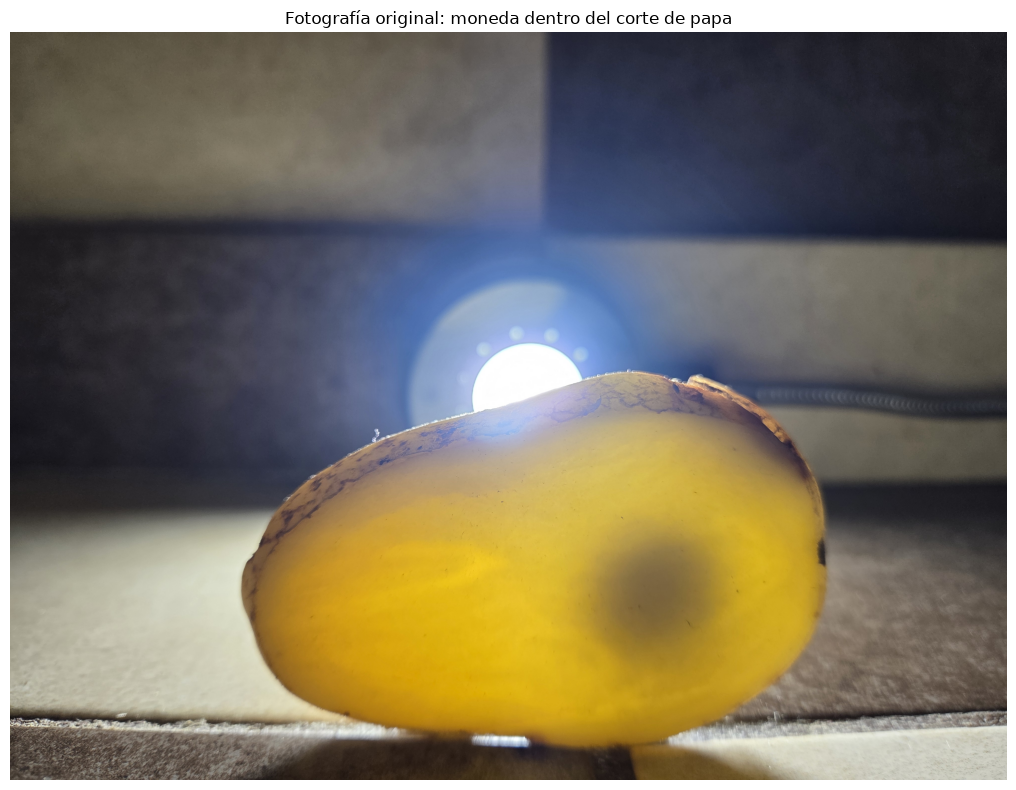

In [2]:
plt.figure(figsize=(12, 8))
plt.imshow(image_rgb)
plt.title("Fotografía original: moneda dentro del corte de papa")
plt.axis("off")
plt.tight_layout()
plt.show()

## 3. Detección de bordes

Para la papa se usa el canal de saturación, pues separa el amarillo del fondo mejor que la luminancia. Para la moneda se calcula la magnitud del gradiente Sobel sobre una versión suavizada. La búsqueda comienza en el centro geométrico del corte y evalúa circunferencias progresivamente hacia los extremos. Esto favorece la moneda y evita seleccionar la sombra estructural de la zona superior derecha.

In [3]:
# Borde de la papa a partir del canal de saturación.
saturation_blur = cv2.GaussianBlur(hsv[:, :, 1], (GAUSSIAN_SIZE, GAUSSIAN_SIZE), 0)
potato_edges = cv2.Canny(saturation_blur, POTATO_CANNY_LOW, POTATO_CANNY_HIGH)

# Banda geométrica para descartar bordes de la mesa, la lámpara y textura interior.
edge_y, edge_x = np.nonzero(potato_edges)
radial_position = np.sqrt(
    ((edge_x - 1080) / 670) ** 2 + ((edge_y - 1070) / 470) ** 2
)
valid_outer_edge = (
    (edge_x >= 380)
    & (edge_x <= 1720)
    & (edge_y >= 600)
    & (edge_y <= 1430)
    & (radial_position >= 0.78)
    & (radial_position <= 1.30)
    & ~((edge_y < 735) & (edge_x > 820) & (edge_x < 1160))
)
potato_edge_points = np.column_stack(
    (edge_x[valid_outer_edge], edge_y[valid_outer_edge])
).astype(np.int32)

if len(potato_edge_points) < 5:
    raise RuntimeError("No hay suficientes puntos para construir el contorno de la papa.")

potato_contour = cv2.convexHull(potato_edge_points.reshape(-1, 1, 2))
moments = cv2.moments(potato_contour)
potato_center = np.array(
    [moments["m10"] / moments["m00"], moments["m01"] / moments["m00"]]
)

# Búsqueda radial de la moneda desde el centro de la papa.
gray_smooth = cv2.GaussianBlur(gray, (31, 31), 0)
gradient_x = cv2.Sobel(gray_smooth, cv2.CV_32F, 1, 0, ksize=3)
gradient_y = cv2.Sobel(gray_smooth, cv2.CV_32F, 0, 1, ksize=3)
gradient_magnitude = cv2.magnitude(gradient_x, gradient_y)

angles = np.linspace(0, 2 * np.pi, 180, endpoint=False)
cosines, sines = np.cos(angles), np.sin(angles)
coin_candidates = []

for candidate_y in COIN_CENTER_Y_RANGE:
    for candidate_x in COIN_CENTER_X_RANGE:
        if cv2.pointPolygonTest(
            potato_contour, (float(candidate_x), float(candidate_y)), False
        ) < 0:
            continue
        distance_to_center = float(
            np.linalg.norm(np.array([candidate_x, candidate_y]) - potato_center)
        )
        for candidate_radius in range(
            COIN_MIN_RADIUS, COIN_MAX_RADIUS + 1, COIN_RADIUS_STEP
        ):
            ring_x = np.clip(
                np.round(candidate_x + candidate_radius * cosines).astype(int),
                0,
                gray.shape[1] - 1,
            )
            ring_y = np.clip(
                np.round(candidate_y + candidate_radius * sines).astype(int),
                0,
                gray.shape[0] - 1,
            )
            ring_gradient = gradient_magnitude[ring_y, ring_x]

            inner_x = np.clip(
                np.round(candidate_x + 0.45 * candidate_radius * cosines).astype(int),
                0,
                gray.shape[1] - 1,
            )
            inner_y = np.clip(
                np.round(candidate_y + 0.45 * candidate_radius * sines).astype(int),
                0,
                gray.shape[0] - 1,
            )
            outer_x = np.clip(
                np.round(candidate_x + 1.18 * candidate_radius * cosines).astype(int),
                0,
                gray.shape[1] - 1,
            )
            outer_y = np.clip(
                np.round(candidate_y + 1.18 * candidate_radius * sines).astype(int),
                0,
                gray.shape[0] - 1,
            )

            radial_contrast = float(
                np.mean(gray_smooth[outer_y, outer_x])
                - np.mean(gray_smooth[inner_y, inner_x])
            )
            edge_completeness = float(np.percentile(ring_gradient, 25))
            circular_score = float(
                np.mean(ring_gradient)
                + 0.70 * edge_completeness
                + 0.45 * max(radial_contrast, 0)
                - DISTANCE_PENALTY * distance_to_center
            )
            coin_candidates.append(
                (
                    circular_score,
                    candidate_x,
                    candidate_y,
                    candidate_radius,
                    distance_to_center,
                    radial_contrast,
                )
            )

if not coin_candidates:
    raise RuntimeError("No se generaron candidatos circulares dentro de la papa.")

best_candidate = max(coin_candidates, key=lambda candidate: candidate[0])
coin_score, coin_x, coin_y, coin_radius, coin_distance, coin_contrast = best_candidate
upper_right_scores = [
    candidate[0]
    for candidate in coin_candidates
    if candidate[1] > potato_center[0]
    and candidate[2] < potato_center[1] - 150
]
upper_right_max_score = max(upper_right_scores)
selection_margin = coin_score - upper_right_max_score

print(f"Puntos de borde usados para la papa: {len(potato_edge_points):,}")
print(f"Centro geométrico de la papa: ({potato_center[0]:.1f}, {potato_center[1]:.1f})")
print(f"Moneda detectada: centro=({coin_x}, {coin_y}), radio={coin_radius} píxeles a escala 0.5")
print(f"Distancia desde el centro de la papa: {coin_distance:.1f} píxeles")
print(f"Contraste radial del candidato: {coin_contrast:.2f}")
print(f"Margen frente a la zona superior derecha: {selection_margin:.2f} puntos")

Puntos de borde usados para la papa: 4,094
Centro geométrico de la papa: (1061.7, 1085.2)
Moneda detectada: centro=(1290, 1120), radio=145 píxeles a escala 0.5
Distancia desde el centro de la papa: 231.0 píxeles
Contraste radial del candidato: 48.72
Margen frente a la zona superior derecha: 13.08 puntos


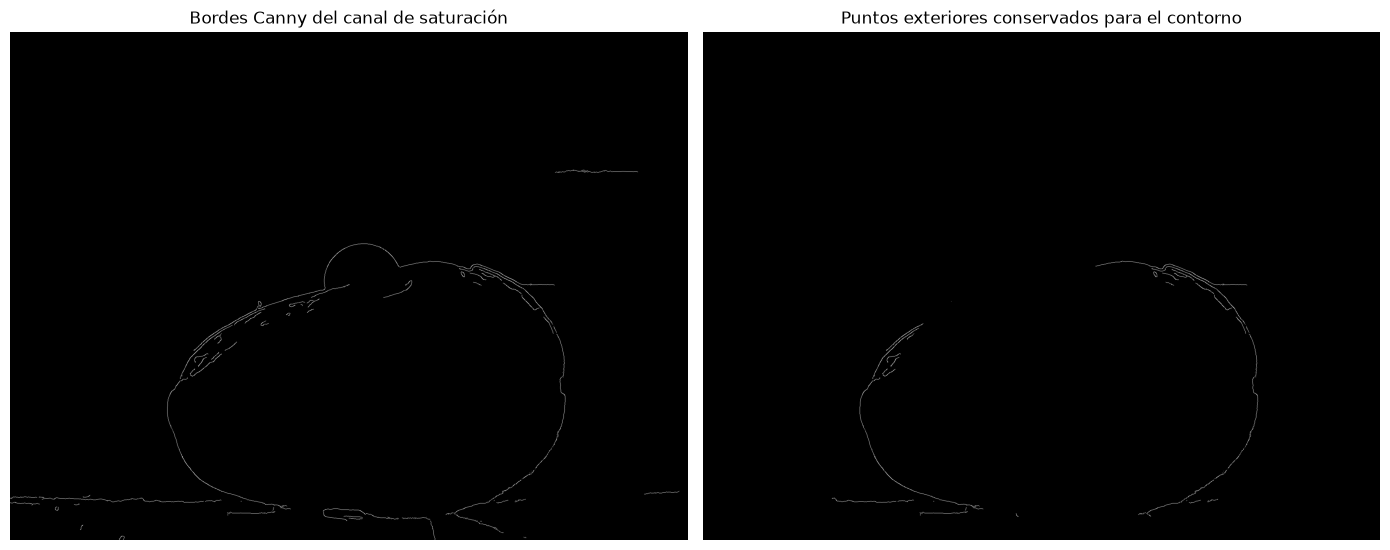

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].imshow(potato_edges, cmap="gray")
axes[0].set_title("Bordes Canny del canal de saturación")
axes[0].set_axis_off()

diagnostic = np.zeros_like(potato_edges)
diagnostic[potato_edge_points[:, 1], potato_edge_points[:, 0]] = 255
axes[1].imshow(diagnostic, cmap="gray")
axes[1].set_title("Puntos exteriores conservados para el contorno")
axes[1].set_axis_off()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "mapa_bordes.png", dpi=170, bbox_inches="tight")
plt.show()

## 4. Contorno de la moneda superpuesto sobre la fotografía

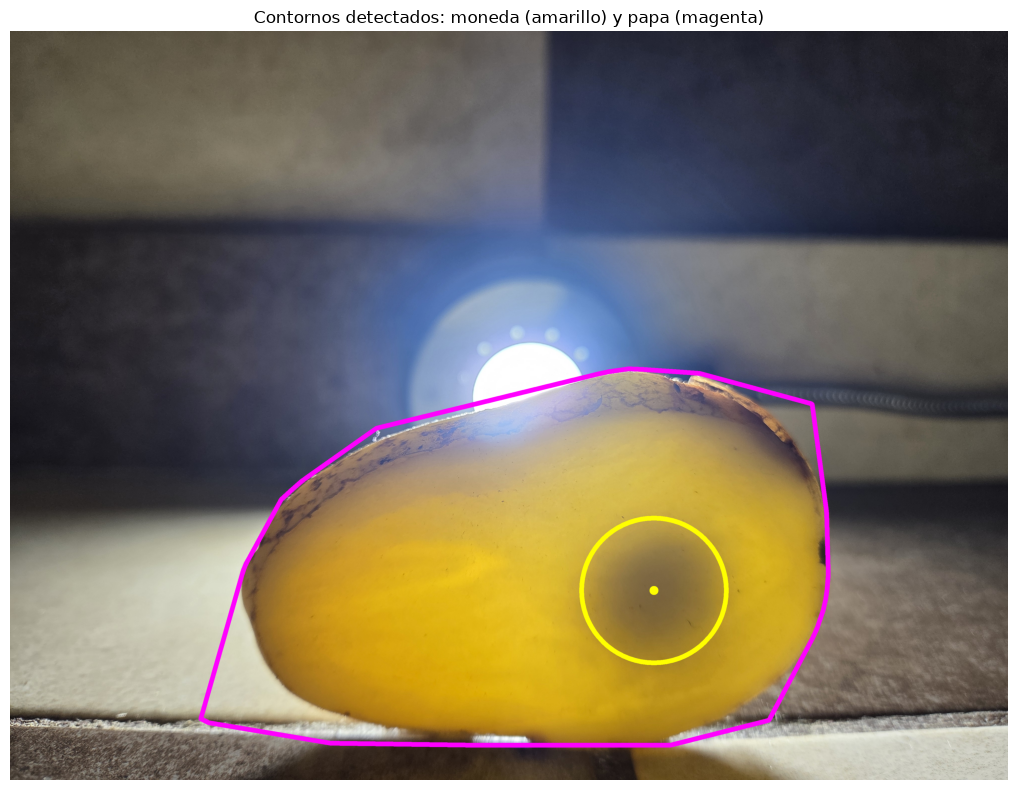

In [5]:
overlay_bgr = image_bgr.copy()
scale_back = 1.0 / SCALE
potato_contour_original = np.round(potato_contour * scale_back).astype(np.int32)
coin_center_original = (round(coin_x * scale_back), round(coin_y * scale_back))
coin_radius_original = round(coin_radius * scale_back)

cv2.drawContours(overlay_bgr, [potato_contour_original], -1, (255, 0, 255), 18)
cv2.circle(overlay_bgr, coin_center_original, coin_radius_original, (0, 255, 255), 18)
cv2.circle(overlay_bgr, coin_center_original, 18, (0, 255, 255), -1)

overlay_rgb = cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB)
cv2.imwrite(str(RESULTS_DIR / "contorno_moneda_superpuesto.png"), overlay_bgr)

plt.figure(figsize=(12, 8))
plt.imshow(overlay_rgb)
plt.title("Contornos detectados: moneda (amarillo) y papa (magenta)")
plt.axis("off")
plt.tight_layout()
plt.show()

## 5. Estimación del área relativa

Como ambas áreas están expresadas en píxeles cuadrados de la misma fotografía, no se necesita convertir a centímetros para calcular una proporción:

\[
\text{Área relativa (\%)} =
\frac{\pi r_{moneda}^{2}}{A_{contorno\ de\ papa}}\times 100
\]

El resultado representa una aproximación proyectada en 2D. La difusión de la luz y el cierre convexo del borde son las principales fuentes de incertidumbre.

In [6]:
# El factor de escala se corrige en ambas áreas para reportar píxeles² originales.
coin_area = math.pi * (coin_radius / SCALE) ** 2
potato_area = cv2.contourArea(potato_contour) / (SCALE ** 2)
relative_area = 100.0 * coin_area / potato_area
remaining_area = 100.0 - relative_area

print(f"Área aproximada de la moneda: {coin_area:,.0f} px²")
print(f"Área aproximada del corte de papa: {potato_area:,.0f} px²")
print(f"Área relativa moneda/papa: {relative_area:.2f}%")

Área aproximada de la moneda: 264,208 px²
Área aproximada del corte de papa: 3,052,740 px²
Área relativa moneda/papa: 8.65%


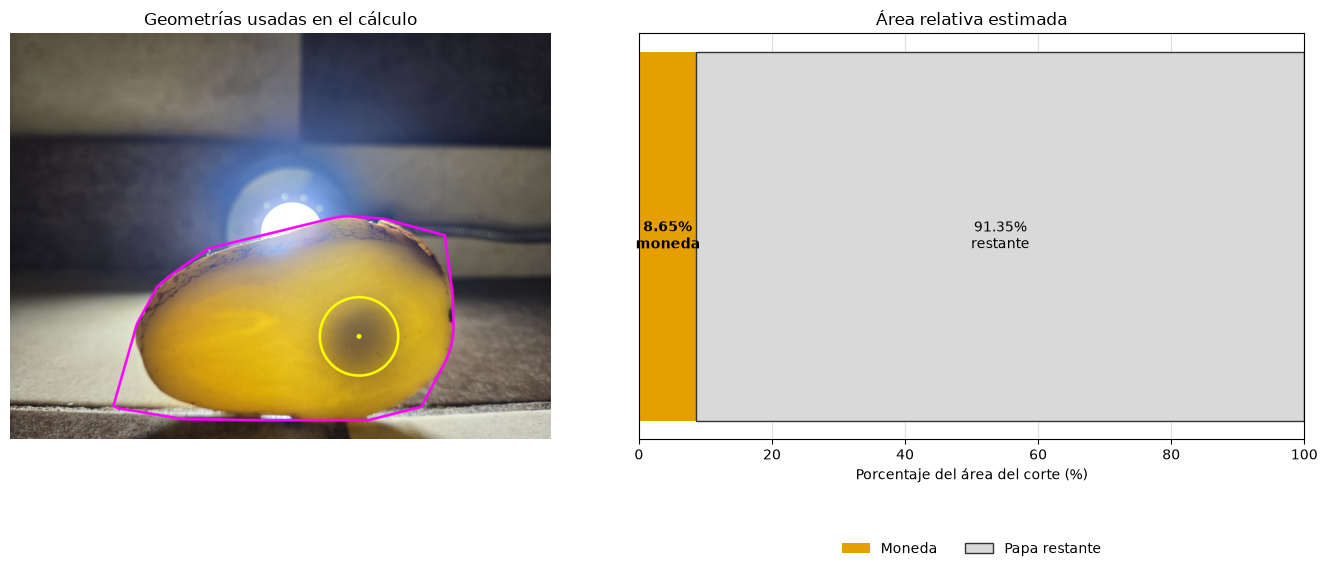

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(overlay_rgb)
axes[0].set_title("Geometrías usadas en el cálculo")
axes[0].set_axis_off()

axes[1].barh([""], [relative_area], color="#E69F00", label="Moneda")
axes[1].barh(
    [""],
    [remaining_area],
    left=[relative_area],
    color="#D9D9D9",
    edgecolor="#333333",
    label="Papa restante",
)
axes[1].set_xlim(0, 100)
axes[1].set_yticks([])
axes[1].set_xlabel("Porcentaje del área del corte (%)")
axes[1].set_title("Área relativa estimada")
axes[1].text(relative_area / 2, 0, f"{relative_area:.2f}%\nmoneda", ha="center", va="center", weight="bold")
axes[1].text(relative_area + remaining_area / 2, 0, f"{remaining_area:.2f}%\nrestante", ha="center", va="center")
axes[1].legend(loc="lower center", bbox_to_anchor=(0.5, -0.32), ncol=2, frameon=False)
axes[1].grid(axis="x", color="#DDDDDD", linewidth=0.8)
axes[1].set_axisbelow(True)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "area_relativa.png", dpi=180, bbox_inches="tight")
plt.show()

## 6. Validación y sensibilidad

In [8]:
def refine_coin_with_blur(blur_size):
    trial_smooth = cv2.GaussianBlur(gray, (blur_size, blur_size), 0)
    trial_gx = cv2.Sobel(trial_smooth, cv2.CV_32F, 1, 0, ksize=3)
    trial_gy = cv2.Sobel(trial_smooth, cv2.CV_32F, 0, 1, ksize=3)
    trial_gradient = cv2.magnitude(trial_gx, trial_gy)
    local_candidates = []
    for trial_y in range(coin_y - 20, coin_y + 21, 10):
        for trial_x in range(coin_x - 20, coin_x + 21, 10):
            trial_distance = float(
                np.linalg.norm(np.array([trial_x, trial_y]) - potato_center)
            )
            for trial_radius in range(
                max(COIN_MIN_RADIUS, coin_radius - 25),
                min(COIN_MAX_RADIUS, coin_radius + 25) + 1,
                COIN_RADIUS_STEP,
            ):
                ring_x = np.clip(
                    np.round(trial_x + trial_radius * cosines).astype(int),
                    0,
                    gray.shape[1] - 1,
                )
                ring_y = np.clip(
                    np.round(trial_y + trial_radius * sines).astype(int),
                    0,
                    gray.shape[0] - 1,
                )
                ring_gradient = trial_gradient[ring_y, ring_x]
                inner_x = np.clip(
                    np.round(trial_x + 0.45 * trial_radius * cosines).astype(int),
                    0,
                    gray.shape[1] - 1,
                )
                inner_y = np.clip(
                    np.round(trial_y + 0.45 * trial_radius * sines).astype(int),
                    0,
                    gray.shape[0] - 1,
                )
                outer_x = np.clip(
                    np.round(trial_x + 1.18 * trial_radius * cosines).astype(int),
                    0,
                    gray.shape[1] - 1,
                )
                outer_y = np.clip(
                    np.round(trial_y + 1.18 * trial_radius * sines).astype(int),
                    0,
                    gray.shape[0] - 1,
                )
                contrast = float(
                    np.mean(trial_smooth[outer_y, outer_x])
                    - np.mean(trial_smooth[inner_y, inner_x])
                )
                completeness = float(np.percentile(ring_gradient, 25))
                score = float(
                    np.mean(ring_gradient)
                    + 0.70 * completeness
                    + 0.45 * max(contrast, 0)
                    - DISTANCE_PENALTY * trial_distance
                )
                local_candidates.append((score, trial_x, trial_y, trial_radius))
    return max(local_candidates, key=lambda candidate: candidate[0])


def potato_area_with_thresholds(low_threshold, high_threshold):
    trial_edges = cv2.Canny(saturation_blur, low_threshold, high_threshold)
    trial_y, trial_x = np.nonzero(trial_edges)
    trial_radial = np.sqrt(((trial_x - 1080) / 670) ** 2 + ((trial_y - 1070) / 470) ** 2)
    keep = (
        (trial_x >= 380)
        & (trial_x <= 1720)
        & (trial_y >= 600)
        & (trial_y <= 1430)
        & (trial_radial >= 0.78)
        & (trial_radial <= 1.30)
        & ~((trial_y < 735) & (trial_x > 820) & (trial_x < 1160))
    )
    points = np.column_stack((trial_x[keep], trial_y[keep])).astype(np.int32)
    contour = cv2.convexHull(points.reshape(-1, 1, 2))
    return cv2.contourArea(contour) / (SCALE ** 2)


sensitivity_rows = []
for blur_size, canny_pair in zip((27, 31, 35), ((18, 54), (20, 60), (22, 66))):
    _, trial_x, trial_y, trial_radius = refine_coin_with_blur(blur_size)
    trial_potato_area = potato_area_with_thresholds(*canny_pair)
    trial_coin_area = math.pi * (trial_radius / SCALE) ** 2
    trial_relative = 100 * trial_coin_area / trial_potato_area
    sensitivity_rows.append(
        {
            "Gauss moneda": blur_size,
            "Canny": f"{canny_pair[0]}/{canny_pair[1]}",
            "centro": f"({trial_x}, {trial_y})",
            "radio_escala_05": int(trial_radius),
            "area_relativa_pct": round(trial_relative, 2),
        }
    )

print("Sensibilidad de parámetros cercanos:")
for row in sensitivity_rows:
    print(row)

sensitivity_values = [row["area_relativa_pct"] for row in sensitivity_rows]
sensitivity_min = min(sensitivity_values)
sensitivity_max = max(sensitivity_values)
print(f"Rango observado: {sensitivity_min:.2f}% a {sensitivity_max:.2f}%")

Sensibilidad de parámetros cercanos:
{'Gauss moneda': 27, 'Canny': '18/54', 'centro': '(1290, 1120)', 'radio_escala_05': 145, 'area_relativa_pct': 8.25}
{'Gauss moneda': 31, 'Canny': '20/60', 'centro': '(1290, 1120)', 'radio_escala_05': 145, 'area_relativa_pct': 8.65}
{'Gauss moneda': 35, 'Canny': '22/66', 'centro': '(1290, 1120)', 'radio_escala_05': 150, 'area_relativa_pct': 9.37}
Rango observado: 8.25% a 9.37%


In [9]:
# Comprobaciones automáticas de coherencia.
assert 0 < relative_area < 100, "La proporción debe estar entre 0 y 100%."
assert coin_area < potato_area, "El área de la moneda debe ser menor que la de la papa."
assert len(potato_contour) >= 4, "El contorno de la papa debe tener varios vértices."
assert len(sensitivity_rows) == 3, "Deben completarse las tres pruebas de sensibilidad."
assert cv2.pointPolygonTest(potato_contour, (float(coin_x), float(coin_y)), False) >= 0
assert selection_margin > 0, "La moneda debe superar a los candidatos de la zona superior derecha."

metrics = {
    "imagen": str(IMAGE_PATH),
    "dimensiones_originales": [int(image_bgr.shape[1]), int(image_bgr.shape[0])],
    "centro_moneda_px_original": list(coin_center_original),
    "radio_moneda_px_original": int(coin_radius_original),
    "area_moneda_px2": round(coin_area, 2),
    "area_papa_px2": round(potato_area, 2),
    "area_relativa_pct": round(relative_area, 2),
    "sensibilidad_pct": [round(sensitivity_min, 2), round(sensitivity_max, 2)],
    "centro_papa_escala_05": [round(float(potato_center[0]), 2), round(float(potato_center[1]), 2)],
    "distancia_moneda_desde_centro_escala_05": round(float(coin_distance), 2),
    "contraste_radial_moneda": round(float(coin_contrast), 2),
    "margen_vs_zona_superior_derecha": round(float(selection_margin), 2),
    "criterio_seleccion": "búsqueda circular desde el centro de la papa hacia los extremos",
    "parametros": {
        "escala": SCALE,
        "gaussiano": GAUSSIAN_SIZE,
        "canny_papa": [POTATO_CANNY_LOW, POTATO_CANNY_HIGH],
        "penalizacion_distancia": DISTANCE_PENALTY,
        "rango_radio_escala_05": [COIN_MIN_RADIUS, COIN_MAX_RADIUS],
    },
}
(RESULTS_DIR / "metricas.json").write_text(
    json.dumps(metrics, ensure_ascii=False, indent=2), encoding="utf-8"
)
print("Validaciones superadas. Métricas guardadas en resultados/metricas.json")

Validaciones superadas. Métricas guardadas en resultados/metricas.json


## 7. Conclusiones

- El contorno circular de la moneda se detectó mediante gradientes, contraste radial y búsqueda desde el centro; el borde exterior de la papa se obtuvo con Canny sobre saturación.
- El porcentaje calculado es una **aproximación del área proyectada**, no una medición física en cm².
- La validación exige que la moneda sea menor que la papa, que la proporción esté entre 0 y 100% y que los ajustes cercanos produzcan resultados comparables.
- La principal limitación es óptica: el borde de la sombra es difuso por el espesor de la papa y la iluminación posterior. La anomalía estructural superior derecha se controló mediante el criterio de distancia al centro y continuidad circular.

### Reproducibilidad

Ejecutar todas las celdas desde el directorio que contiene `moneda en papa.jpg`. Las versiones directas de las dependencias se encuentran en `requirements.txt`.